# 11 — HuggingFace Sentiment + TimeSeriesTransformer

Combina dos modelos de HuggingFace:

| Paso | Modelo HF | Tarea |
|------|-----------|-------|
| 1 | **FinBERT** (`ProsusAI/finbert`) | Clasificar cada headline como positivo / neutro / negativo con probabilidades reales |
| 2 | **TimeSeriesTransformer** (`huggingface/time-series-transformer-tourism-monthly`) | Predecir los índices usando las series de precios + el sentimiento como `feat_dynamic_real` |

### Por qué FinBERT sobre reglas léxicas
FinBERT está pre-entrenado en textos financieros (Reuters, Bloomberg). Distingue matices que las reglas del notebook 10 no capturan:
- *"volatility spikes"* puede ser positivo (oportunidad) o negativo (riesgo) según contexto
- *"central bank policy shift"* tiene connotaciones distintas en 2015 vs 2022

### Por qué network metrics
Index_F es Bitcoin. Las métricas de red (`ActiveNodes`, `TxVolume`, `HashRate`) son indicadores on-chain directamente relacionados con la salud de la red Bitcoin, lo que las convierte en predictores naturales de Index_F. Las incluimos junto al sentimiento.

```bash
pip install transformers accelerate torch
```

In [15]:
import sys, warnings
import numpy as np
import pandas as pd
import torch
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
from utils import load_data, compute_rmse, make_submission, train_val_split, INDEX_COLS

data         = load_data()
train_full   = data['train_indices'][INDEX_COLS]
test_dates   = data['test_dates'].index
train, val   = train_val_split(train_full, val_size=252)

news_train   = data['train_news']
news_test    = data['test_news']
news_all     = pd.concat([news_train, news_test]).sort_index()

net_train    = data['train_network_metrics']
net_test     = data['test_network_metrics']
net_all      = pd.concat([net_train, net_test]).sort_index()
NET_COLS     = ['ActiveNodes', 'TxVolume', 'HashRate']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Train: {train.shape}  |  Val: {val.shape}  |  Test: {len(test_dates)} dias')
print(f'News total: {len(news_all)}  |  Network metrics: {net_all.shape}')

Device: cuda
Train: (2095, 6)  |  Val: (252, 6)  |  Test: 262 dias
News total: 1084  |  Network metrics: (2609, 3)


## 1 — Sentimiento con FinBERT

FinBERT devuelve tres probabilidades por headline: `positive`, `negative`, `neutral`.
Usamos la diferencia `p_positive - p_negative` como señal escalar, y también guardamos cada probabilidad por separado para dárselas al modelo de series temporales.

In [16]:
from transformers import pipeline as hf_pipeline

print('Cargando FinBERT (ProsusAI/finbert)...')
# device=0 si hay GPU, -1 si solo CPU
finbert_device = 0 if torch.cuda.is_available() else -1
finbert = hf_pipeline(
    'text-classification',
    model='ProsusAI/finbert',
    tokenizer='ProsusAI/finbert',
    top_k=None,          # devuelve las 3 clases con sus probabilidades
    device=finbert_device,
    truncation=True,
    max_length=128,
)
print('FinBERT cargado.')

Cargando FinBERT (ProsusAI/finbert)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT cargado.


In [17]:
def score_headlines_finbert(news_df, batch_size=32):
    """
    Corre FinBERT sobre todos los headlines y devuelve un DataFrame con:
    - sent_score: p_positive - p_negative  (en [-1, 1])
    - sent_pos, sent_neg, sent_neu: probabilidades brutas
    Indexado por fecha.
    """
    headlines = news_df['Headline'].tolist()
    dates     = news_df.index.tolist()

    rows = []
    for i in range(0, len(headlines), batch_size):
        batch = headlines[i:i+batch_size]
        results = finbert(batch)
        for date, res in zip(dates[i:i+batch_size], results):
            scores = {r['label']: r['score'] for r in res}
            p_pos = scores.get('positive', 0.0)
            p_neg = scores.get('negative', 0.0)
            p_neu = scores.get('neutral',  0.0)
            rows.append({
                'Date':      date,
                'sent_score': p_pos - p_neg,
                'sent_pos':   p_pos,
                'sent_neg':   p_neg,
                'sent_neu':   p_neu,
            })
        if (i // batch_size) % 5 == 0:
            print(f'  {min(i+batch_size, len(headlines))}/{len(headlines)} headlines procesados')

    df = pd.DataFrame(rows).set_index('Date')
    df.index = pd.to_datetime(df.index)
    return df


print('Analizando sentimiento con FinBERT...')
sent_raw = score_headlines_finbert(news_all)
print(f'Headlines procesados: {len(sent_raw)}')
print(sent_raw.head(5))

Analizando sentimiento con FinBERT...
  32/1084 headlines procesados
  192/1084 headlines procesados
  352/1084 headlines procesados
  512/1084 headlines procesados
  672/1084 headlines procesados
  832/1084 headlines procesados
  992/1084 headlines procesados
Headlines procesados: 1084
            sent_score  sent_pos  sent_neg  sent_neu
Date                                                
2015-01-02    0.929494  0.942241  0.012747  0.045013
2015-01-07    0.927449  0.939267  0.011817  0.048916
2015-01-12   -0.800492  0.017816  0.818308  0.163876
2015-01-15   -0.720842  0.073567  0.794409  0.132025
2015-01-16   -0.814267  0.020120  0.834386  0.145494


## 2 — Construir series diarias de sentimiento y red

In [18]:
all_dates = train_full.index.union(test_dates)

# Reindexar sentimiento a todas las fechas (0 en dias sin noticias)
sent_daily = sent_raw.reindex(all_dates).fillna(0)

# Shift(1): las noticias del día D se publican durante D, por lo que solo
# son usables para predecir D+1. Aplicar ANTES de los rolling.
sent_daily[['sent_score', 'sent_pos', 'sent_neg', 'sent_neu']] = \
    sent_daily[['sent_score', 'sent_pos', 'sent_neg', 'sent_neu']].shift(1).fillna(0)

# Rolling momentum (sobre sent_score ya shifteado — no necesita shift adicional)
for w in [5, 10, 20]:
    sent_daily[f'sent_roll{w}'] = sent_daily['sent_score'].rolling(w, min_periods=1).mean()

# Network metrics normalizadas (log-scale para TxVolume y HashRate)
net_daily = net_all[NET_COLS].reindex(all_dates).ffill().bfill()
net_daily['log_TxVolume'] = np.log1p(net_daily['TxVolume'])
net_daily['log_HashRate'] = np.log1p(net_daily['HashRate'])
net_daily_norm = (net_daily - net_daily.loc[train_full.index].mean()) / \
                  net_daily.loc[train_full.index].std().clip(lower=1e-8)

# Features dinámicas que se pasan al TST
SENT_FEAT_COLS = ['sent_score', 'sent_roll5', 'sent_roll10', 'sent_roll20']
NET_FEAT_COLS  = ['ActiveNodes', 'log_TxVolume', 'log_HashRate']

dyn_feats = pd.concat([
    sent_daily[SENT_FEAT_COLS],
    net_daily_norm[['ActiveNodes', 'log_TxVolume', 'log_HashRate']]
], axis=1).fillna(0)

N_DYN = len(dyn_feats.columns)
print(f'Features dinamicas por dia: {N_DYN}')
print(dyn_feats.columns.tolist())
print(dyn_feats.describe().round(3))

Features dinamicas por dia: 7
['sent_score', 'sent_roll5', 'sent_roll10', 'sent_roll20', 'ActiveNodes', 'log_TxVolume', 'log_HashRate']
       sent_score  sent_roll5  sent_roll10  sent_roll20  ActiveNodes  \
count    2609.000    2609.000     2609.000     2609.000     2609.000   
mean       -0.017      -0.017       -0.017       -0.017        0.179   
std         0.517       0.232        0.160        0.112        1.189   
min        -0.957      -0.874       -0.632       -0.419       -0.785   
25%         0.000      -0.172       -0.128       -0.096       -0.699   
50%         0.000       0.000       -0.008       -0.016       -0.295   
75%         0.000       0.170        0.093        0.060        0.756   
max         0.934       0.746        0.507        0.328        6.180   

       log_TxVolume  log_HashRate  
count      2609.000      2609.000  
mean          0.110         0.010  
std           1.005         0.974  
min          -2.115        -2.953  
25%          -0.429        -0.612  

## 3 — Visualizar sentimiento FinBERT vs precios

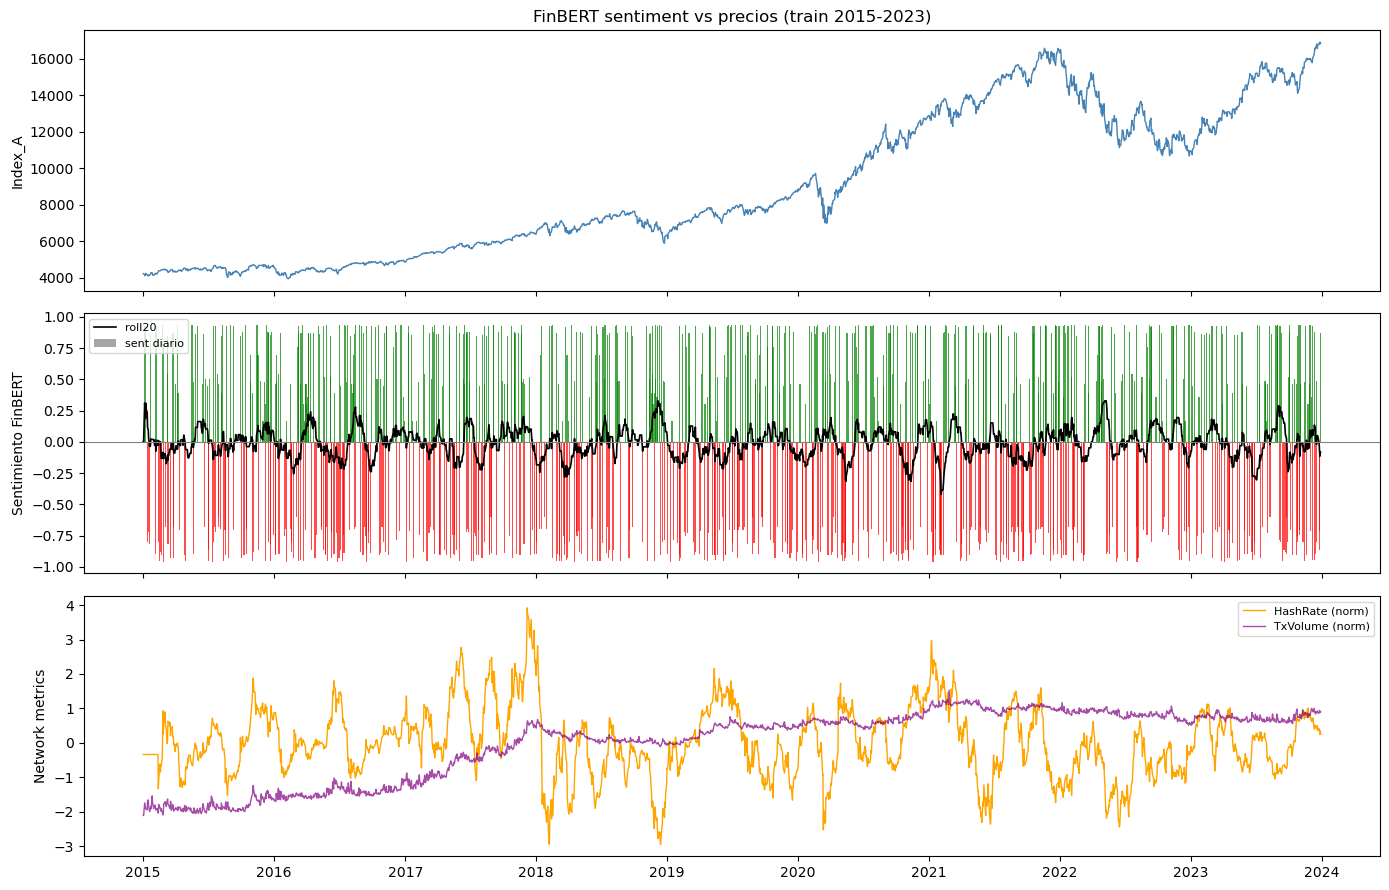

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

sent_tr = sent_daily.reindex(train_full.index)
colors  = ['green' if v > 0 else ('red' if v < 0 else 'gray') for v in sent_tr['sent_score']]

axes[0].plot(train_full.index, train_full['Index_A'], color='steelblue', lw=1)
axes[0].set_ylabel('Index_A')
axes[0].set_title('FinBERT sentiment vs precios (train 2015-2023)')

axes[1].bar(sent_tr.index, sent_tr['sent_score'], color=colors, width=3, alpha=0.7, label='sent diario')
axes[1].plot(sent_tr.index, sent_tr['sent_roll20'], color='black', lw=1.2, label='roll20')
axes[1].set_ylabel('Sentimiento FinBERT')
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].legend(fontsize=8)

net_tr = net_daily_norm.reindex(train_full.index)
axes[2].plot(net_tr.index, net_tr['log_HashRate'],  label='HashRate (norm)', color='orange', lw=1)
axes[2].plot(net_tr.index, net_tr['log_TxVolume'], label='TxVolume (norm)', color='purple', lw=1, alpha=0.7)
axes[2].set_ylabel('Network metrics')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('finbert_sentiment_network.png', dpi=100)
plt.show()

## 4 — TimeSeriesTransformer con features dinámicas

Usamos `num_dynamic_real_features=N_DYN` para pasar el sentimiento y las métricas de red como covariables temporales al modelo.

In [20]:
from transformers import TimeSeriesTransformerConfig, TimeSeriesTransformerForPrediction
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

LAGS_SEQ = [1, 2, 3, 5, 7, 10, 20, 30, 60]
CONTEXT  = 64
PAST_LEN = CONTEXT + max(LAGS_SEQ)   # 124


def build_dataset_with_feats(series: np.ndarray, dyn: np.ndarray,
                              past_len: int, horizon: int):
    """
    Empaqueta sentimiento + network metrics como time features adicionales
    (junto al time index lineal). Así evitamos usar num_dynamic_real_features,
    que tiene bugs de shape en HF transformers con horizontes largos.

    past_time_features / future_time_features: (N, T, 1 + N_DYN)
      canal 0: índice temporal lineal [0,1]
      canales 1..N_DYN: features dinámicas (sentimiento ya shifteado + network)
    """
    n_dyn = dyn.shape[1]
    pv_list, fv_list, tp_list, tf_list = [], [], [], []

    for i in range(past_len, len(series) - horizon + 1):
        pv_list.append(series[i - past_len: i])
        fv_list.append(series[i: i + horizon])

        t_past = np.linspace(0, 1, past_len).reshape(-1, 1)           # (past_len, 1)
        d_past = dyn[i - past_len: i]                                  # (past_len, N_DYN)
        tp_list.append(np.concatenate([t_past, d_past], axis=1))       # (past_len, 1+N_DYN)

        t_fut  = np.linspace(0, 1, horizon).reshape(-1, 1)             # (horizon, 1)
        d_fut  = dyn[i: i + horizon]                                   # (horizon, N_DYN)
        tf_list.append(np.concatenate([t_fut, d_fut], axis=1))         # (horizon, 1+N_DYN)

    pv = torch.tensor(np.array(pv_list), dtype=torch.float32)
    fv = torch.tensor(np.array(fv_list), dtype=torch.float32)
    tp = torch.tensor(np.array(tp_list), dtype=torch.float32)
    tf = torch.tensor(np.array(tf_list), dtype=torch.float32)
    return pv, fv, tp, tf


def train_tst_with_sentiment(price_series, dyn_array, col_name, horizon,
                              epochs=25, batch=16, lr=1e-4,
                              fit_scaler_on=None):
    sc = StandardScaler()
    sc.fit((fit_scaler_on if fit_scaler_on is not None else price_series).reshape(-1, 1))
    scaled = sc.transform(price_series.reshape(-1, 1)).ravel()

    n_time_feats = 1 + dyn_array.shape[1]   # tiempo lineal + N_DYN features

    cfg = TimeSeriesTransformerConfig(
        prediction_length=horizon,
        context_length=CONTEXT,
        lags_sequence=LAGS_SEQ,
        num_time_features=n_time_feats,
        num_dynamic_real_features=0,         # evitamos el API problemático
        num_static_categorical_features=0,
        num_static_real_features=0,
        d_model=64,
        encoder_layers=2, decoder_layers=2,
        encoder_attention_heads=4, decoder_attention_heads=4,
        encoder_ffn_dim=128, decoder_ffn_dim=128,
        dropout=0.1,
        distribution_output='student_t',
    )
    model = TimeSeriesTransformerForPrediction(cfg).to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr)

    pv, fv, tp, tf = build_dataset_with_feats(scaled, dyn_array, PAST_LEN, horizon)
    obs = torch.ones_like(pv)
    ds  = TensorDataset(pv, fv, tp, tf, obs)
    dl  = DataLoader(ds, batch_size=batch, shuffle=True)

    model.train()
    for ep in range(epochs):
        total = 0.0
        for pv_b, fv_b, tp_b, tf_b, om_b in dl:
            pv_b = pv_b.to(device); fv_b = fv_b.to(device)
            tp_b = tp_b.to(device); tf_b = tf_b.to(device)
            om_b = om_b.to(device)
            opt.zero_grad()
            out = model(
                past_values=pv_b,
                past_time_features=tp_b,
                past_observed_mask=om_b,
                future_values=fv_b,
                future_time_features=tf_b,
            )
            out.loss.backward()
            opt.step()
            total += out.loss.item() * len(pv_b)
        if (ep + 1) % 5 == 0:
            print(f'  [{col_name}] Epoch {ep+1}/{epochs}  loss={total/len(ds):.5f}')

    # Inferencia
    model.eval()
    sc_last = torch.tensor(scaled[-PAST_LEN:], dtype=torch.float32).unsqueeze(0).to(device)
    om_inf  = torch.ones(1, PAST_LEN, dtype=torch.float32).to(device)

    t_past_inf = np.linspace(0, 1, PAST_LEN).reshape(-1, 1)
    d_past_inf = dyn_array[len(price_series)-PAST_LEN: len(price_series)]
    tp_inf = torch.tensor(
        np.concatenate([t_past_inf, d_past_inf], axis=1)[None], dtype=torch.float32
    ).to(device)

    t_fut_inf = np.linspace(0, 1, horizon).reshape(-1, 1)
    d_fut_inf = dyn_array[len(price_series): len(price_series)+horizon]
    tf_inf = torch.tensor(
        np.concatenate([t_fut_inf, d_fut_inf], axis=1)[None], dtype=torch.float32
    ).to(device)

    with torch.no_grad():
        out = model.generate(
            past_values=sc_last,
            past_time_features=tp_inf,
            past_observed_mask=om_inf,
            future_time_features=tf_inf,
        )
    samples = out.sequences.cpu().numpy()
    median  = np.median(samples[0], axis=0)
    return sc.inverse_transform(median.reshape(-1, 1)).ravel(), model, sc

print('Funciones TST con sentimiento definidas.')

Funciones TST con sentimiento definidas.


## 5 — Validación local

In [21]:
# dyn_array_full cubre train_full + test (todos los periodos)
# Se indexa por posición: los primeros len(train) pasos son train,
# los siguientes len(val) son val, el resto es test.
dyn_array_full = dyn_feats.reindex(all_dates).fillna(0).values   # (T_total, N_DYN)

val_preds = {}
print('Entrenando TST con sentimiento FinBERT + network (validacion)...')
for col in INDEX_COLS:
    print(f'\n=== {col} ===')
    price_tr = train[col].values   # (len(train),)

    # Pasamos dyn_array_full completo:
    # - entrenamiento usa índices [0 : len(train)]
    # - inferencia usa past  = [len(train)-PAST_LEN : len(train)]
    #                  future= [len(train) : len(train)+len(val)]  ← val features
    pred_arr, _, _ = train_tst_with_sentiment(
        price_series=price_tr,
        dyn_array=dyn_array_full,
        col_name=col,
        horizon=len(val),
        epochs=20,
        fit_scaler_on=price_tr,
    )
    val_preds[col] = pred_arr

pred_val_df = pd.DataFrame(val_preds, index=val.index)
rmse = compute_rmse(val, pred_val_df)
print(f'\n[HF Sentiment TST] RMSE validacion = {rmse:,.2f}')
per = np.sqrt(((val.values - pred_val_df.values)**2).mean(axis=0))
for col, r in zip(INDEX_COLS, per):
    print(f'  {col}: {r:,.2f}')
print()
print('Referencia HF TST sin sentimiento (nb 07): ~1.924')

Entrenando TST con sentimiento FinBERT + network (validacion)...

=== Index_A ===
  [Index_A] Epoch 5/20  loss=-0.25514
  [Index_A] Epoch 10/20  loss=-0.68243
  [Index_A] Epoch 15/20  loss=-0.90128
  [Index_A] Epoch 20/20  loss=-1.05021

=== Index_B ===
  [Index_B] Epoch 5/20  loss=-0.28497
  [Index_B] Epoch 10/20  loss=-0.71558
  [Index_B] Epoch 15/20  loss=-0.88772
  [Index_B] Epoch 20/20  loss=-1.00307

=== Index_C ===
  [Index_C] Epoch 5/20  loss=-0.19930
  [Index_C] Epoch 10/20  loss=-0.74576
  [Index_C] Epoch 15/20  loss=-0.91305
  [Index_C] Epoch 20/20  loss=-1.00136

=== Index_D ===
  [Index_D] Epoch 5/20  loss=-0.23880
  [Index_D] Epoch 10/20  loss=-0.66505
  [Index_D] Epoch 15/20  loss=-0.86662
  [Index_D] Epoch 20/20  loss=-0.99482

=== Index_E ===
  [Index_E] Epoch 5/20  loss=-0.26881
  [Index_E] Epoch 10/20  loss=-0.70288
  [Index_E] Epoch 15/20  loss=-0.89025
  [Index_E] Epoch 20/20  loss=-1.03411

=== Index_F ===
  [Index_F] Epoch 5/20  loss=-0.30801
  [Index_F] Epoch 10

## 6 — Reentrenar con train completo y generar submission

In [22]:
test_preds = {}
print('Reentrenando con train completo + generando prediccion test...')
for col in INDEX_COLS:
    print(f'\n=== {col} ===')
    price_full = train_full[col].values
    # Incluir tanto train_full como test en el array dinamico
    pred_arr, _, _ = train_tst_with_sentiment(
        price_series=price_full,
        dyn_array=dyn_array_full,
        col_name=col,
        horizon=len(test_dates),
        epochs=20,
        fit_scaler_on=train[col].values,  # scaler fiteado solo en train, sin val
    )
    test_preds[col] = pred_arr

pred_test_df = pd.DataFrame(test_preds, index=test_dates)
make_submission(pred_test_df, 'submission_11_hf_sentiment.csv')
pred_test_df.head()

Reentrenando con train completo + generando prediccion test...

=== Index_A ===
  [Index_A] Epoch 5/20  loss=-0.30303
  [Index_A] Epoch 10/20  loss=-0.71109
  [Index_A] Epoch 15/20  loss=-0.87121
  [Index_A] Epoch 20/20  loss=-0.99933

=== Index_B ===
  [Index_B] Epoch 5/20  loss=-0.25336
  [Index_B] Epoch 10/20  loss=-0.67883
  [Index_B] Epoch 15/20  loss=-0.85874
  [Index_B] Epoch 20/20  loss=-0.98806

=== Index_C ===
  [Index_C] Epoch 5/20  loss=-0.22529
  [Index_C] Epoch 10/20  loss=-0.65343
  [Index_C] Epoch 15/20  loss=-0.78638
  [Index_C] Epoch 20/20  loss=-0.91731

=== Index_D ===
  [Index_D] Epoch 5/20  loss=-0.23922
  [Index_D] Epoch 10/20  loss=-0.66159
  [Index_D] Epoch 15/20  loss=-0.84798
  [Index_D] Epoch 20/20  loss=-0.99873

=== Index_E ===
  [Index_E] Epoch 5/20  loss=-0.29137
  [Index_E] Epoch 10/20  loss=-0.68859
  [Index_E] Epoch 15/20  loss=-0.87694
  [Index_E] Epoch 20/20  loss=-0.99894

=== Index_F ===
  [Index_F] Epoch 5/20  loss=-0.30537
  [Index_F] Epoch 10/2

,Index_A,Index_B,Index_C,Index_D,Index_E,Index_F
Date,,,,,,
2024-01-01,16340.318359,4657.714355,20.590973,16075.912109,126.786263,41930.164062
2024-01-02,16184.223633,4639.562012,20.420057,16066.731445,126.968285,42864.402344
2024-01-03,15890.003906,4604.070801,20.158833,15932.884766,125.226105,41938.863281
2024-01-04,15730.496094,4563.391602,20.069578,15668.687500,123.982231,42224.195312
2024-01-05,15584.925781,4525.858887,20.298590,15712.754883,123.631935,42540.988281


## 7 — Comparativa visual vs HF TST base

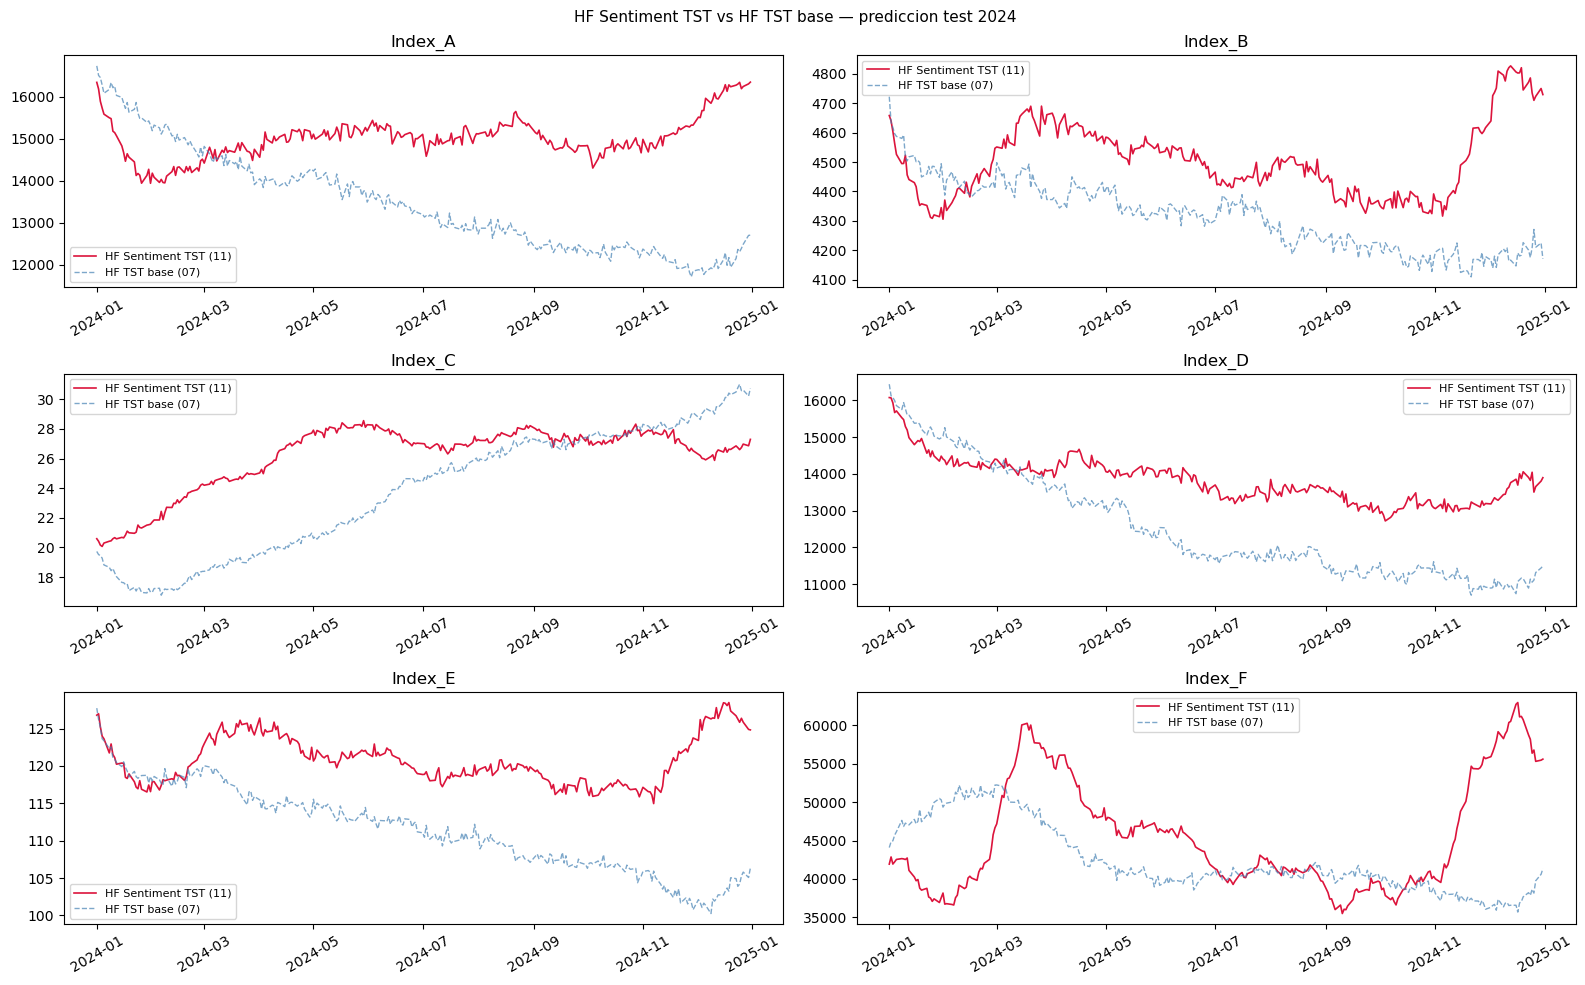

In [23]:
import os
sub07_path = os.path.join('submissions', 'submission_07a_hf_tst.csv')
if os.path.exists(sub07_path):
    sub07 = pd.read_csv(sub07_path, parse_dates=[0], index_col=0).reindex(test_dates)[INDEX_COLS]

    fig, axes = plt.subplots(3, 2, figsize=(16, 10))
    for ax, col in zip(axes.flatten(), INDEX_COLS):
        ax.plot(test_dates, pred_test_df[col],
                label='HF Sentiment TST (11)', color='crimson', lw=1.2)
        ax.plot(test_dates, sub07[col],
                label='HF TST base (07)', color='steelblue',
                lw=1.0, linestyle='--', alpha=0.7)
        ax.set_title(col)
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('HF Sentiment TST vs HF TST base — prediccion test 2024', fontsize=11)
    plt.tight_layout()
    plt.savefig('hf_sentiment_tst_vs_base.png', dpi=100)
    plt.show()
else:
    print('Ejecuta primero 07_HuggingFace.ipynb para tener la referencia')

## 8 — Análisis: ¿qué tan útil fue el sentimiento?

Compara el sentimiento medio de los períodos donde el modelo acertó la dirección vs donde falló.

Correlacion sentimiento ~ acierto de direccion: 0.187


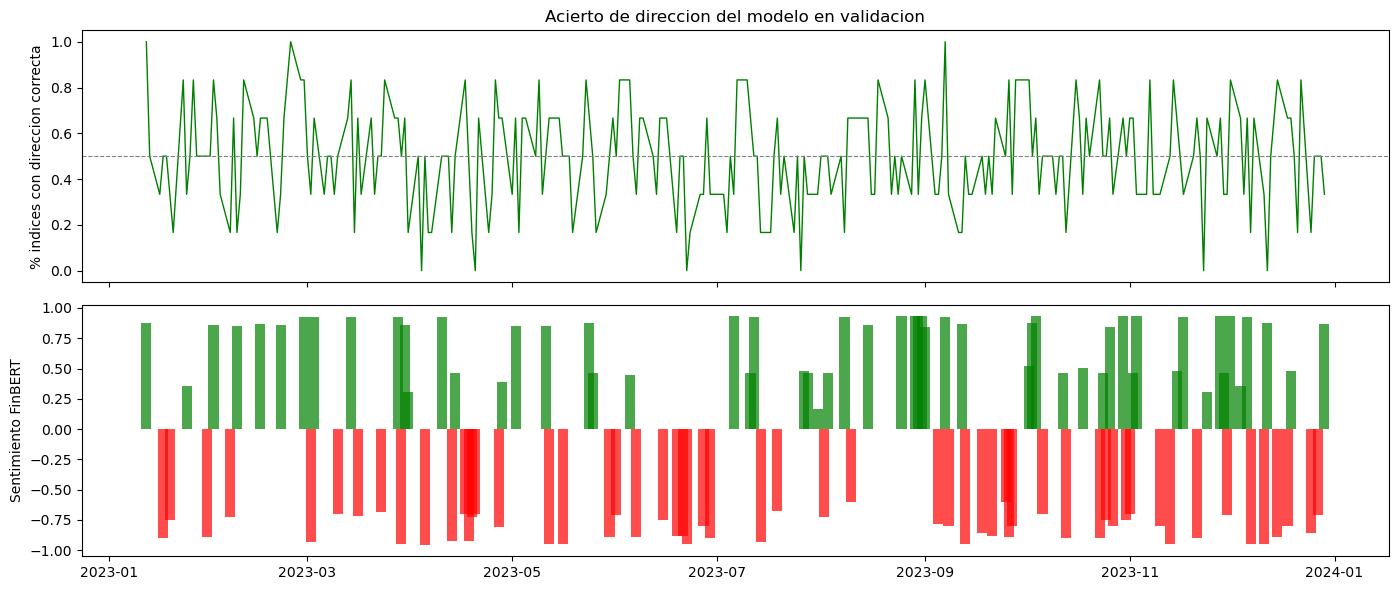

In [24]:
# Calcular dirección predicha vs dirección real en validación
# (solo podemos hacer esto en val porque tenemos los valores reales)
real_dir  = np.sign(val.diff().fillna(0).values)        # (252, 6)
pred_dir  = np.sign(pred_val_df.diff().fillna(0).values)
correct   = (real_dir == pred_dir).mean(axis=1)          # acierto diario medio

sent_val  = sent_daily.reindex(val.index)['sent_score'].values

# Correlación entre sentimiento y acierto de dirección
corr = np.corrcoef(sent_val, correct)[0, 1]
print(f'Correlacion sentimiento ~ acierto de direccion: {corr:.3f}')

# Visualizar
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(val.index, correct, color='green', lw=1)
axes[0].axhline(0.5, color='gray', lw=0.8, linestyle='--')
axes[0].set_ylabel('% indices con direccion correcta')
axes[0].set_title('Acierto de direccion del modelo en validacion')

axes[1].bar(val.index, sent_val, color=[
    'green' if v > 0 else ('red' if v < 0 else 'gray') for v in sent_val
], width=3, alpha=0.7)
axes[1].set_ylabel('Sentimiento FinBERT')
plt.tight_layout()
plt.savefig('sentiment_vs_directional_accuracy.png', dpi=100)
plt.show()